# Student Performance Prediction System
### UCI Student Performance Dataset — ML Algorithms
---

## Setup & Data Preparation

In [46]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
# Load dataset (student-mat.csv uses semicolon separator)
data_path = Path("student-mat.csv")
if not data_path.is_file():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        candidate_path = candidate / "student-mat.csv"
        if candidate_path.is_file():
            data_path = candidate_path
            break

if not data_path.is_file():
    raise FileNotFoundError(
        f"{data_path.name} not found. Place the dataset file in the notebook directory "
        f"({Path.cwd()}) or update the path."
    )
    

df = pd.read_csv(data_path, sep=";")

# Preview the data
print("Shape:", df.shape)
df.head() # Display the first few rows of the dataset (five actually as default)


Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [47]:
# Encode categorical columns (convert text to numbers)
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Define input features (exclude G1, G2, G3 grade columns)
feature_cols = [c for c in df_encoded.columns if c not in ['G1', 'G2', 'G3']]
X = df_encoded[feature_cols]

# Regression target: final numeric grade (0–20)
y_reg = df_encoded['G3']

# Classification target: Pass (1) if G3 >= 10, Fail (0) otherwise
y_clf = (df_encoded['G3'] >= 10).astype(int)

print("Features:", len(feature_cols))
print("Pass:", y_clf.sum(), "| Fail:", (y_clf == 0).sum())


Features: 30
Pass: 265 | Fail: 130


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12768\3300420932.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


In [48]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

# Scale features (required for KNN, SVM, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])


Training samples: 316
Testing samples:  79


---
## A — Linear Regression
**Task:** Predict the final numeric grade (G3) — Regression

In [49]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Create the model
model_lr = LinearRegression()

# Train the model
model_lr.fit(X_train, y_reg_train)

# Make predictions
y_pred_lr = model_lr.predict(X_test)

# Evaluate the model
mae  = mean_absolute_error(y_reg_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr))
r2   = r2_score(y_reg_test, y_pred_lr)

print("Linear Regression Results:")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")


Linear Regression Results:
  MAE  : 3.4948
  RMSE : 4.3062
  R²   : 0.0957


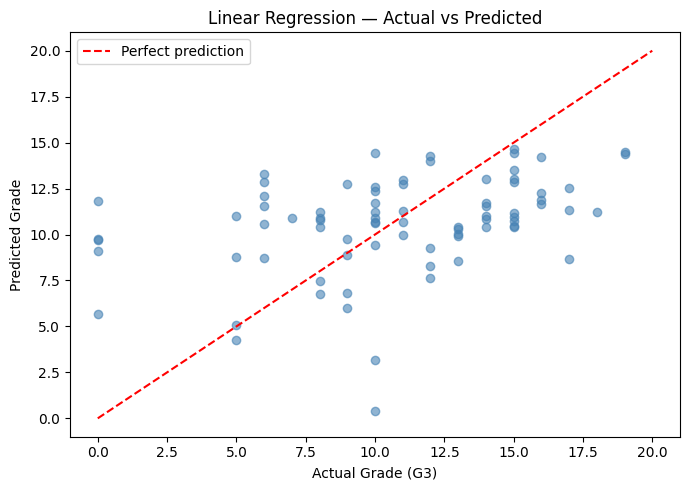

In [50]:
# Plot actual vs predicted grades
plt.figure(figsize=(7, 5))
plt.scatter(y_reg_test, y_pred_lr, alpha=0.6, color='steelblue')
plt.plot([0, 20], [0, 20], 'r--', label='Perfect prediction')
plt.xlabel('Actual Grade (G3)')
plt.ylabel('Predicted Grade')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()


---
## B — Logistic Regression
**Task:** Predict Pass or Fail — Classification

In [51]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the model
model_log = LogisticRegression(max_iter=1000, random_state=42)

# Train the model (use scaled features)
model_log.fit(X_train_scaled, y_clf_train)

# Make predictions
y_pred_log = model_log.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_clf_test, y_pred_log)
print("Logistic Regression Results:")
print(f"  Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_clf_test, y_pred_log, target_names=['Fail', 'Pass']))


Logistic Regression Results:
  Accuracy: 0.7468

Classification Report:
              precision    recall  f1-score   support

        Fail       0.71      0.44      0.55        27
        Pass       0.76      0.90      0.82        52

    accuracy                           0.75        79
   macro avg       0.73      0.67      0.69        79
weighted avg       0.74      0.75      0.73        79



---
## C — K-Nearest Neighbors (KNN)
**Task:** Predict Pass or Fail — Classification

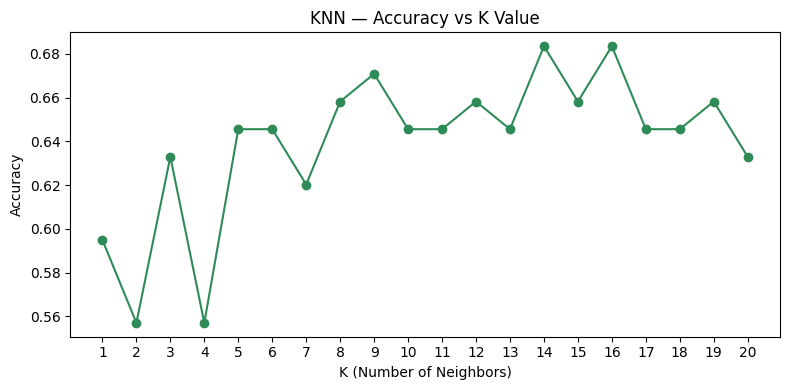

Best K: 14  |  Accuracy: 0.6835


In [52]:
# Import KNN
from sklearn.neighbors import KNeighborsClassifier

# Find the best K by testing K = 1 to 20
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_clf_train)
    k_scores.append(accuracy_score(y_clf_test, knn.predict(X_test_scaled)))

# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), k_scores, marker='o', color='seagreen')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs K Value')
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

# Select the best K
best_k = k_scores.index(max(k_scores)) + 1
print(f"Best K: {best_k}  |  Accuracy: {max(k_scores):.4f}")


In [53]:
# Create the model with best K
model_knn = KNeighborsClassifier(n_neighbors=best_k)

# Train the model
model_knn.fit(X_train_scaled, y_clf_train)

# Make predictions
y_pred_knn = model_knn.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_clf_test, y_pred_knn)
print(f"KNN (K={best_k}) Results:")
print(f"  Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_clf_test, y_pred_knn, target_names=['Fail', 'Pass']))


KNN (K=14) Results:
  Accuracy: 0.6835

Classification Report:
              precision    recall  f1-score   support

        Fail       0.62      0.19      0.29        27
        Pass       0.69      0.94      0.80        52

    accuracy                           0.68        79
   macro avg       0.66      0.56      0.54        79
weighted avg       0.67      0.68      0.62        79



---
## D — Decision Trees
**Task:** Predict Pass or Fail — Classification
**Output:** Interpretable classification model

In [54]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Create the model (max_depth=5 to avoid overfitting)
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
model_dt.fit(X_train, y_clf_train)

# Make predictions
y_pred_dt = model_dt.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_clf_test, y_pred_dt)
print("Decision Tree Results:")
print(f"  Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_clf_test, y_pred_dt, target_names=['Fail', 'Pass']))


Decision Tree Results:
  Accuracy: 0.7342

Classification Report:
              precision    recall  f1-score   support

        Fail       0.80      0.30      0.43        27
        Pass       0.72      0.96      0.83        52

    accuracy                           0.73        79
   macro avg       0.76      0.63      0.63        79
weighted avg       0.75      0.73      0.69        79



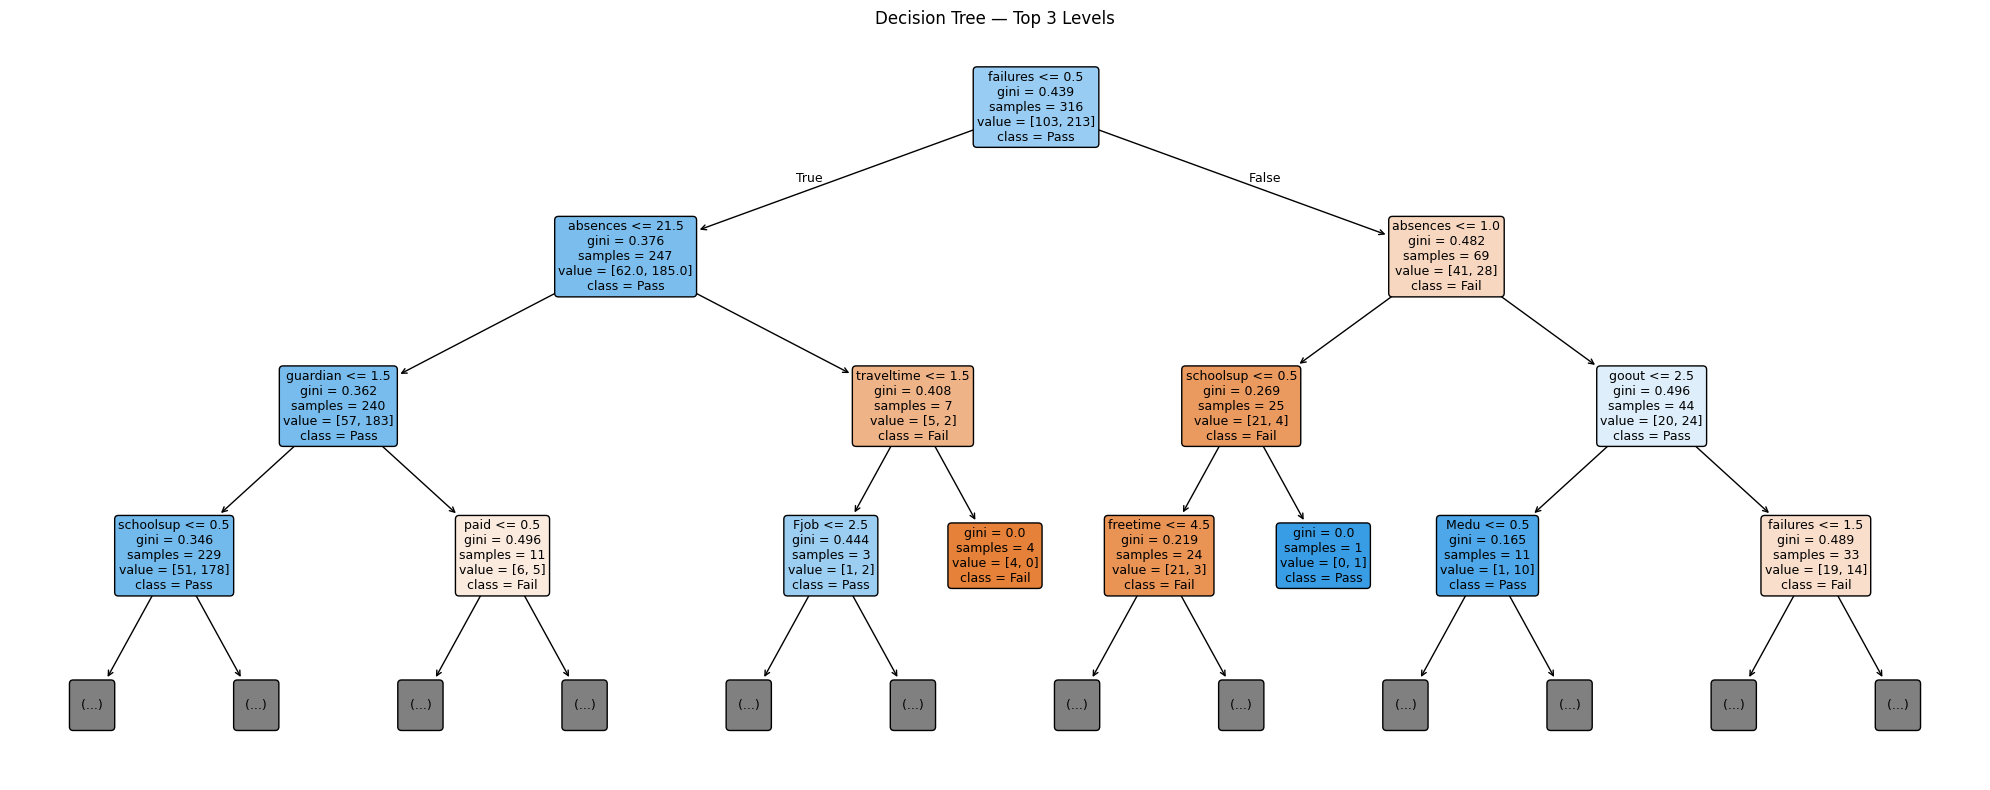

In [55]:
# Visualize the top 3 levels of the Decision Tree
plt.figure(figsize=(20, 8))
plot_tree(
    model_dt,
    feature_names=feature_cols,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree — Top 3 Levels")
plt.tight_layout()
plt.show()


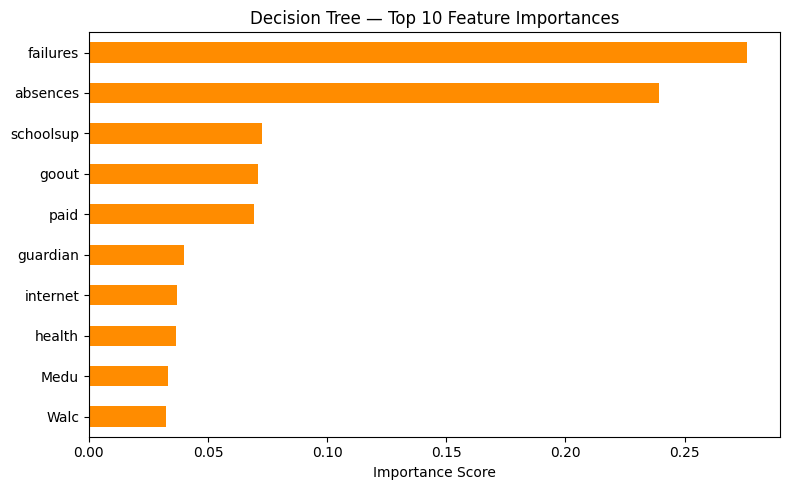

In [56]:
# Plot feature importances
importances = pd.Series(model_dt.feature_importances_, index=feature_cols)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='darkorange')
plt.title('Decision Tree — Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


---
## E — Naive Bayes (Gaussian)
**Task:** Predict Pass or Fail — Classification
**Experiment:** Compare Gaussian NB with other models

In [57]:
# Import Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Create the model
model_nb = GaussianNB()

# Train the model
model_nb.fit(X_train_scaled, y_clf_train)

# Make predictions
y_pred_nb = model_nb.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_clf_test, y_pred_nb)
print("Gaussian Naive Bayes Results:")
print(f"  Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_clf_test, y_pred_nb, target_names=['Fail', 'Pass']))


Gaussian Naive Bayes Results:
  Accuracy: 0.7089

Classification Report:
              precision    recall  f1-score   support

        Fail       0.64      0.33      0.44        27
        Pass       0.72      0.90      0.80        52

    accuracy                           0.71        79
   macro avg       0.68      0.62      0.62        79
weighted avg       0.70      0.71      0.68        79



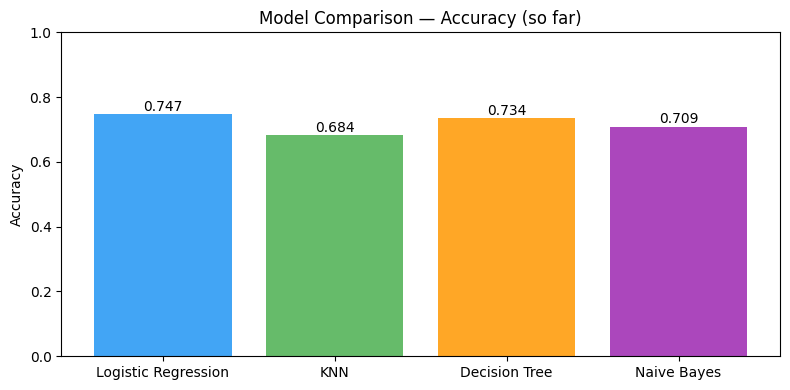

In [58]:
# Compare Naive Bayes accuracy with previously trained models
model_names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Naive Bayes']
accuracies  = [
    accuracy_score(y_clf_test, y_pred_log),
    accuracy_score(y_clf_test, y_pred_knn),
    accuracy_score(y_clf_test, y_pred_dt),
    accuracy_score(y_clf_test, y_pred_nb),
]

plt.figure(figsize=(8, 4))
plt.bar(model_names, accuracies, color=['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Comparison — Accuracy (so far)')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()


---
## F — Ensemble Methods
**Task:** Classification + Regression
**Models:** Random Forest, AdaBoost, Gradient Boosting

### F.1 — Random Forest

In [59]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# ── Classification (Pass / Fail) ──────────────────────────────
# Create the model
model_rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model_rf_clf.fit(X_train, y_clf_train)

# Make predictions
y_pred_rf = model_rf_clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_clf_test, y_pred_rf)
print("Random Forest — Classification Results:")
print(f"  Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_clf_test, y_pred_rf, target_names=['Fail', 'Pass']))


Random Forest — Classification Results:
  Accuracy: 0.7215

Classification Report:
              precision    recall  f1-score   support

        Fail       0.73      0.30      0.42        27
        Pass       0.72      0.94      0.82        52

    accuracy                           0.72        79
   macro avg       0.72      0.62      0.62        79
weighted avg       0.72      0.72      0.68        79



In [60]:
# ── Regression (predict final grade) ─────────────────────────
# Create the model
model_rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model_rf_reg.fit(X_train, y_reg_train)

# Make predictions
y_pred_rf_reg = model_rf_reg.predict(X_test)

# Evaluate the model
mae  = mean_absolute_error(y_reg_test, y_pred_rf_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_reg))
r2   = r2_score(y_reg_test, y_pred_rf_reg)

print("Random Forest — Regression Results:")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")


Random Forest — Regression Results:
  MAE  : 2.9958
  RMSE : 3.7184
  R²   : 0.3257


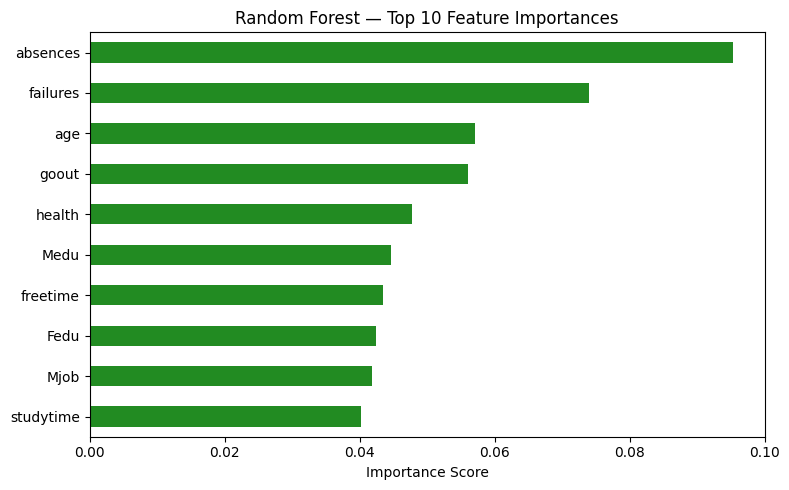

In [61]:
# Plot feature importances from Random Forest
importances = pd.Series(model_rf_clf.feature_importances_, index=feature_cols)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='forestgreen')
plt.title('Random Forest — Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


### F.2 — AdaBoost

In [62]:
# Import AdaBoost
from sklearn.ensemble import AdaBoostClassifier

# Create the model
model_ada = AdaBoostClassifier(n_estimators=100, random_state=42)

# Train the model
model_ada.fit(X_train, y_clf_train)

# Make predictions
y_pred_ada = model_ada.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_clf_test, y_pred_ada)
print("AdaBoost Results:")
print(f"  Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_clf_test, y_pred_ada, target_names=['Fail', 'Pass']))


AdaBoost Results:
  Accuracy: 0.7468

Classification Report:
              precision    recall  f1-score   support

        Fail       0.71      0.44      0.55        27
        Pass       0.76      0.90      0.82        52

    accuracy                           0.75        79
   macro avg       0.73      0.67      0.69        79
weighted avg       0.74      0.75      0.73        79



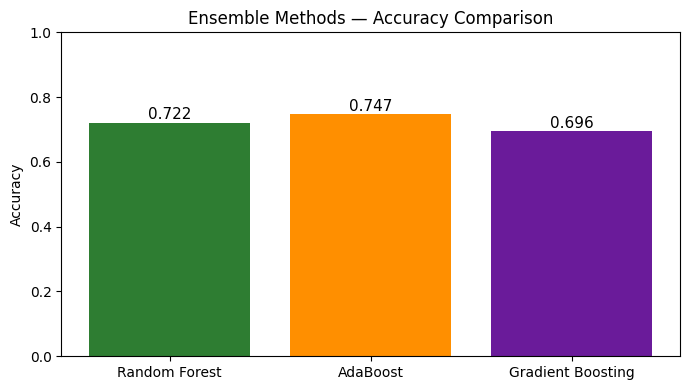

In [64]:
# Compare all three ensemble models
ensemble_names = ['Random Forest', 'AdaBoost', 'Gradient Boosting']
ensemble_accs  = [
    accuracy_score(y_clf_test, y_pred_rf),
    accuracy_score(y_clf_test, y_pred_ada),
    accuracy_score(y_clf_test, y_pred_gb)
]

plt.figure(figsize=(7, 4))
plt.bar(ensemble_names, ensemble_accs, color=['#2E7D32', '#FF8F00', '#6A1B9A'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Ensemble Methods — Accuracy Comparison')
for i, v in enumerate(ensemble_accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()


---
## G — Support Vector Machines (SVM)
**Task:** Predict Pass or Fail — Classification
**Experiments:** Linear kernel vs RBF kernel

In [ ]:
# Import SVM
from sklearn.svm import SVC

# ── Linear Kernel ─────────────────────────────────────────────
# Create the model
model_svm_linear = SVC(kernel='linear', C=1.0, random_state=42)

# Train the model (use scaled features)
model_svm_linear.fit(X_train_scaled, y_clf_train)

# Make predictions
y_pred_svm_linear = model_svm_linear.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_clf_test, y_pred_svm_linear)
print("SVM — Linear Kernel Results:")
print(f"  Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_clf_test, y_pred_svm_linear, target_names=['Fail', 'Pass']))


SVM — Linear Kernel Results:
  Accuracy: 0.7089

Classification Report:
              precision    recall  f1-score   support

        Fail       0.70      0.26      0.38        27
        Pass       0.71      0.94      0.81        52

    accuracy                           0.71        79
   macro avg       0.71      0.60      0.59        79
weighted avg       0.71      0.71      0.66        79



In [ ]:
# ── RBF Kernel ────────────────────────────────────────────────
# Create the model
model_svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Train the model (use scaled features)
model_svm_rbf.fit(X_train_scaled, y_clf_train)

# Make predictions
y_pred_svm_rbf = model_svm_rbf.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_clf_test, y_pred_svm_rbf)
print("SVM — RBF Kernel Results:")
print(f"  Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_clf_test, y_pred_svm_rbf, target_names=['Fail', 'Pass']))


SVM — RBF Kernel Results:
  Accuracy: 0.7089

Classification Report:
              precision    recall  f1-score   support

        Fail       0.75      0.22      0.34        27
        Pass       0.70      0.96      0.81        52

    accuracy                           0.71        79
   macro avg       0.73      0.59      0.58        79
weighted avg       0.72      0.71      0.65        79



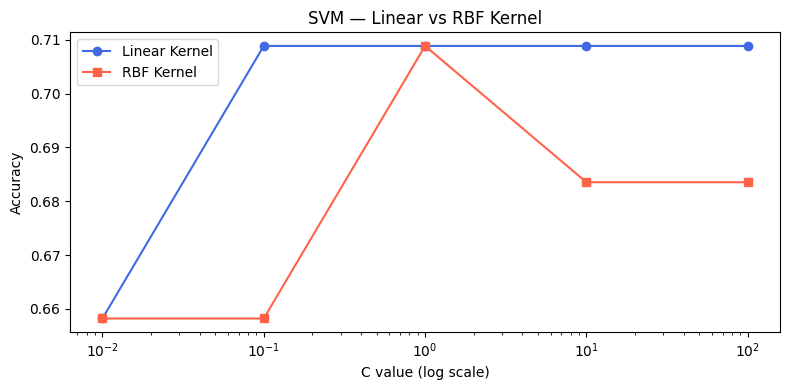

In [ ]:
# Compare Linear vs RBF kernel across different C values
C_values = [0.01, 0.1, 1, 10, 100]
lin_accs, rbf_accs = [], []

for C in C_values:
    # Linear kernel
    svm_l = SVC(kernel='linear', C=C, random_state=42)
    svm_l.fit(X_train_scaled, y_clf_train)
    lin_accs.append(accuracy_score(y_clf_test, svm_l.predict(X_test_scaled)))

    # RBF kernel
    svm_r = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    svm_r.fit(X_train_scaled, y_clf_train)
    rbf_accs.append(accuracy_score(y_clf_test, svm_r.predict(X_test_scaled)))

# Plot comparison
plt.figure(figsize=(8, 4))
plt.plot(C_values, lin_accs, marker='o', label='Linear Kernel', color='royalblue')
plt.plot(C_values, rbf_accs, marker='s', label='RBF Kernel',    color='tomato')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('SVM — Linear vs RBF Kernel')
plt.legend()
plt.tight_layout()
plt.show()


---
## Final Results — All Models Compared

In [ ]:
# Collect accuracy scores for all classification models
model_names = [
    'Logistic Regression',
    'KNN',
    'Decision Tree',
    'Naive Bayes',
    'Random Forest',
    'AdaBoost',
    'Gradient Boosting',
    'SVM (Linear)',
    'SVM (RBF)',
]

all_preds = [
    y_pred_log, y_pred_knn, y_pred_dt, y_pred_nb,
    y_pred_rf,  y_pred_ada, y_pred_gb,
    y_pred_svm_linear, y_pred_svm_rbf,
]

all_accs = [accuracy_score(y_clf_test, p) for p in all_preds]

# Print summary table
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 37)
for name, acc in sorted(zip(model_names, all_accs), key=lambda x: -x[1]):
    print(f"{name:<25} {acc:>10.4f}")


Model                       Accuracy
-------------------------------------
Logistic Regression           0.7468
AdaBoost                      0.7468
Decision Tree                 0.7342
Random Forest                 0.7215
Naive Bayes                   0.7089
SVM (Linear)                  0.7089
SVM (RBF)                     0.7089
Gradient Boosting             0.6962
KNN                           0.6835


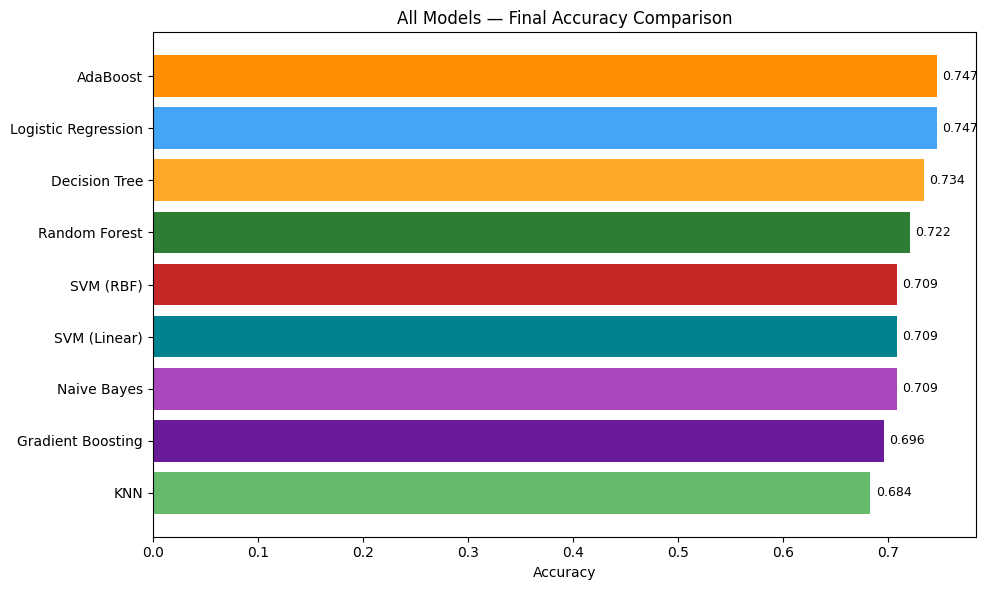

In [ ]:
# Plot final comparison bar chart
colors = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC',
          '#2E7D32', '#FF8F00', '#6A1B9A', '#00838F', '#C62828']

sorted_pairs = sorted(zip(model_names, all_accs, colors), key=lambda x: x[1])
names_sorted  = [p[0] for p in sorted_pairs]
accs_sorted   = [p[1] for p in sorted_pairs]
colors_sorted = [p[2] for p in sorted_pairs]

plt.figure(figsize=(10, 6))
bars = plt.barh(names_sorted, accs_sorted, color=colors_sorted)
plt.xlabel('Accuracy')
plt.title('All Models — Final Accuracy Comparison')
for bar, acc in zip(bars, accs_sorted):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{acc:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()
